In [4]:
dataset["train"].features["label"]

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [5]:
from collections import Counter

labels = dataset["train"]["label"]
counts = Counter(labels)

for label_id, count in sorted(counts.items()):
    label_name = dataset["train"].features["label"].names[label_id]
    print(f"{label_name}: {count}")

World: 30000
Sports: 30000
Business: 30000
Sci/Tech: 30000


### Loading Tokenizer

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
sample_text = "Wall St. Bears Claw Back Into the Black"

tokens = tokenizer(sample_text)
print(tokens)

{'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [8]:
token_strings = tokenizer.convert_ids_to_tokens(tokens["input_ids"])
print(token_strings)

['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '[SEP]']


In [9]:
import torch
torch.cuda.is_available()

True

### Tokenizing the dataset

In [10]:
small_train = dataset["train"].shuffle(seed=42).select(range(4000))
small_test = dataset["test"].shuffle(seed=42).select(range(1000))

print(small_train)
print(small_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 4000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


In [11]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=128
    )

In [12]:
small_train = small_train.map(tokenize, batched=True)
small_test = small_test.map(tokenize, batched=True)

print(small_train)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4000
})


In [13]:
small_train = small_train.rename_column("label", "labels")
small_test = small_test.rename_column("label", "labels")

small_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
small_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(small_train[0])

{'labels': tensor(0), 'input_ids': tensor([  101,  7269, 11498,  2135,  6924,  2011,  9326,  4559, 10134,  2031,
         2716,  2116,  4865,  1998,  3655,  1999,  7269,  2000,  1037,  9190,
         1010,  1996,  2154,  2044,  2324,  2111,  2351,  1999, 18217,  2012,
         1037,  2576,  8320,  1012,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

## Loading DistilBERT base model

In [14]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Fine Tuning on our dataset

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = np.mean(predictions == labels)
    return {"accuracy": accuracy}

In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics,
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.321556,0.892000
2,No log,0.301326,0.901000
3,No log,0.287030,0.908000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=375, training_loss=0.28041357421875, metrics={'train_runtime': 152.2125, 'train_samples_per_second': 78.837, 'train_steps_per_second': 2.464, 'total_flos': 397416370176000.0, 'train_loss': 0.28041357421875, 'epoch': 3.0})

## Training reports

In [19]:
from sklearn.metrics import classification_report

predictions = trainer.predict(small_test)
preds = np.argmax(predictions.predictions, axis=-1)

label_names = dataset["train"].features["label"].names
print(classification_report(predictions.label_ids, preds, target_names=label_names))

              precision    recall  f1-score   support

       World       0.94      0.89      0.91       266
      Sports       0.98      0.96      0.97       246
    Business       0.91      0.84      0.88       246
    Sci/Tech       0.82      0.94      0.88       242

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



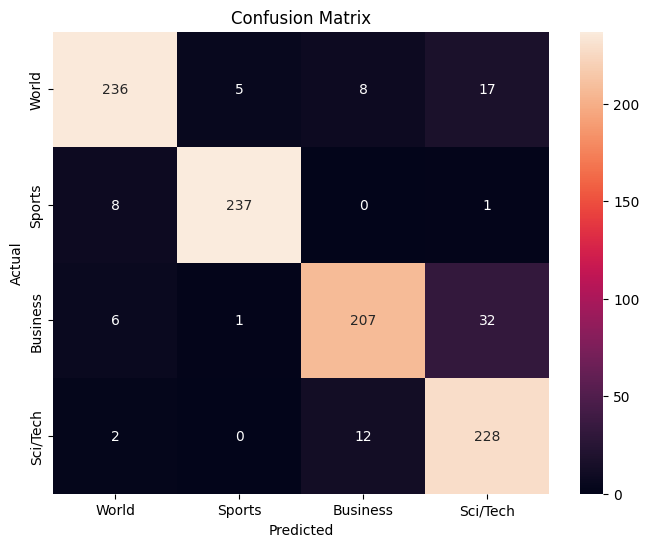

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(predictions.label_ids, preds)
label_names = dataset["train"].features["label"].names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Saving Model

In [21]:
model.save_pretrained("./distilbert-ag-news")
tokenizer.save_pretrained("./distilbert-ag-news")
print("Model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


## Testing it on our own

In [22]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_id = torch.argmax(outputs.logits, dim=-1).item()
    label_names = dataset["train"].features["label"].names
    return label_names[predicted_id]

In [23]:
print(predict("NASA launches new telescope to study distant galaxies"))
print(predict("Manchester United wins the Premier League title"))
print(predict("Federal Reserve raises interest rates again"))

Sci/Tech
Sports
Business


In [24]:
print(predict('Startup Unveils AI Chip That Could Reshape Global Markets'))
print(predict('Tech Giant’s Quantum Breakthrough Sends Investors Into Frenzy'))
print(predict('Leaders Meet to Address Rising Tensions in Eastern Europe'))
print(predict('Underdog Team Stuns Champions in Last-Minute Victory'))
print(predict('Central Bank Announces Major Policy Shift Amid Inflation Concerns'))

Sci/Tech
Sci/Tech
World
Sports
Business


In [25]:
imdb = load_dataset("imdb")
print(imdb)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [26]:
imdb_train = imdb["train"].shuffle(seed=42).select(range(3000))
imdb_test = imdb["test"].shuffle(seed=42).select(range(1000))

In [27]:
imdb_train = imdb_train.map(tokenize, batched=True)
imdb_test = imdb_test.map(tokenize, batched=True)

imdb_train = imdb_train.rename_column("label", "labels")
imdb_test = imdb_test.rename_column("label", "labels")

imdb_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
imdb_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [28]:
sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
sentiment_trainer = Trainer(
    model=sentiment_model,
    args=training_args,
    train_dataset=imdb_train,
    eval_dataset=imdb_test,
    compute_metrics=compute_metrics,
)

sentiment_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.389245,0.831000
2,No log,0.415460,0.834000
3,No log,0.483849,0.831000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=282, training_loss=0.2833979451064522, metrics={'train_runtime': 131.5177, 'train_samples_per_second': 68.432, 'train_steps_per_second': 2.144, 'total_flos': 298051646976000.0, 'train_loss': 0.2833979451064522, 'epoch': 3.0})

In [30]:
imdb_test[0]

{'labels': tensor(1),
 'input_ids': tensor([  101,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  2043,
          1045,  4895, 13203,  5051, 10985,  2135, 12524,  1037,  4595,  4631,
          1010,  1045,  2245,  1045,  2001,  1999,  2005,  2019, 14036,  2332,
         26511,  2466,  1998,  1997,  2607,  9393,  1052,  7959, 13355,  2121,
          2001,  1999,  2009,  1010,  2061,  2054,  2071,  2175,  3308,  1029,
          1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  2200,  2855,
          1010,  2174,  1010,  1045,  3651,  2008,  2023,  2466,  2001,  2055,
          1037,  4595,  2060,  2477,  4661,  2074,  4631,  1012,  1045,  2318,
          6933,  1998,  2481,  1005,  1056,  2644,  2127,  2146,  2044,  1996,
          3185,  3092,  1012,  4067,  2017,  4869,  1010,  6874,  1998, 23786,
          1010,  2005,  5026,  2149,  2107,  1037,  6919,  2135, 11259,  1998,
         29353,  3185,   999,  4067,  2017,  3459,  1010,  2005,  2108,  2920,
          1998, 1

In [31]:
import time

review = "This movie was absolutely fantastic. The acting was superb and I loved every minute of it."

# DistilBERT inference time
start = time.time()
for _ in range(100):
    inputs = tokenizer(review, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(sentiment_model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = sentiment_model(**inputs)
end = time.time()

print(f"DistilBERT avg inference time: {(end-start)/100*1000:.2f}ms")

DistilBERT avg inference time: 6.16ms


In [34]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=256
    )

In [35]:
imdb_train_full = imdb["train"].map(tokenize, batched=True)
imdb_test_full = imdb["test"].map(tokenize, batched=True)

imdb_train_full = imdb_train_full.rename_column("label", "labels")
imdb_test_full = imdb_test_full.rename_column("label", "labels")

imdb_train_full.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
imdb_test_full.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(imdb_train_full)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})


In [36]:
sentiment_model_full = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
training_args_full = TrainingArguments(
    output_dir="./results_full",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs_full",
)

trainer_full = Trainer(
    model=sentiment_model_full,
    args=training_args_full,
    train_dataset=imdb_train_full,
    eval_dataset=imdb_test_full,
    compute_metrics=compute_metrics,
)

trainer_full.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.270038,0.267283,0.885920
2,0.150720,0.309389,0.902760
3,0.065806,0.396450,0.908880


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4689, training_loss=0.17975464404125055, metrics={'train_runtime': 2270.3415, 'train_samples_per_second': 33.035, 'train_steps_per_second': 2.065, 'total_flos': 4967527449600000.0, 'train_loss': 0.17975464404125055, 'epoch': 3.0})

In [39]:
import time

review = "This movie was absolutely fantastic. The acting was superb and I loved every minute of it."

# DistilBERT inference time
start = time.time()
for _ in range(100):
    inputs = tokenizer(review, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(sentiment_model_full.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = sentiment_model_full(**inputs)
end = time.time()

print(f"DistilBERT avg inference time: {(end-start)/100*1000:.2f}ms")

DistilBERT avg inference time: 14.17ms


In [40]:
from huggingface_hub import notebook_login
notebook_login()

In [41]:
sentiment_model_full.push_to_hub("distilbert-imdb-sentiment")
tokenizer.push_to_hub("distilbert-imdb-sentiment")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...vbb4qv_/model.safetensors:   1%|1         | 3.99MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Nikhil-Vaishnav-17/distilbert-imdb-sentiment/commit/744bda8d313ba5aade594127623a4f0fadb59b0f', commit_message='Upload tokenizer', commit_description='', oid='744bda8d313ba5aade594127623a4f0fadb59b0f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Nikhil-Vaishnav-17/distilbert-imdb-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='Nikhil-Vaishnav-17/distilbert-imdb-sentiment'), pr_revision=None, pr_num=None)

In [42]:
print("""
┌─────────────────┬──────────────┬───────────────┬────────────────┬─────────────┐
│ Model           │ Dataset      │ Accuracy      │ Inference Time │ Model Size  │
├─────────────────┼──────────────┼───────────────┼────────────────┼─────────────┤
│ BiLSTM          │ IMDB (25k)   │ 87%           │ <100ms (CPU)   │ ~2.5MB      │
│ DistilBERT      │ IMDB (3k)    │ 83.4%         │ 6.33ms (GPU)   │ ~250MB      │
│ DistilBERT(full)│ IMDB (25k)   │ 90.9%         │ 14.17ms (GPU)  │ ~268MB      │
└─────────────────┴──────────────┴───────────────┴────────────────┴─────────────┘
""")


┌─────────────────┬──────────────┬───────────────┬────────────────┬─────────────┐
│ Model           │ Dataset      │ Accuracy      │ Inference Time │ Model Size  │
├─────────────────┼──────────────┼───────────────┼────────────────┼─────────────┤
│ BiLSTM          │ IMDB (25k)   │ 87%           │ <100ms (CPU)   │ ~2.5MB      │
│ DistilBERT      │ IMDB (3k)    │ 83.4%         │ 6.33ms (GPU)   │ ~250MB      │
│ DistilBERT(full)│ IMDB (25k)   │ 90.9%         │ 14.17ms (GPU)  │ ~268MB      │
└─────────────────┴──────────────┴───────────────┴────────────────┴─────────────┘

